# Modelo de regresión logística

# Programa o Script desarrollado por : Rolando Ortiz Herbas

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
#from mp.mpf import mp.mpf, getcontext
import mpmath as mp
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA


# Lectura del Dataset de entrenamiento : Clientes_Dos_Mil_TransEntrenamiento.csv

In [3]:
#mp.getcontext().prec = 30
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/Clientes_Dos_Mil_numeros.csv"

df = pd.read_csv(ruta , header=0)

In [4]:
mp.dps = 20
df.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV,Y
0,47.0,35,302783,6.0,0.0,20150417,20150417,20180221,20200417,5046,...,1.0,0.0,2.0,1.0,0.0,9,1,1,36,1
1,38.0,38,211366,5.0,0.0,20150220,20150220,20180208,20200220,7044,...,0.0,0.0,2.0,3.0,0.0,9,1,1,40,1
2,13.0,50,323640,1.0,0.0,20150220,20160115,20190218,20200220,0,...,1.0,0.0,1.0,3.0,47.0,8,1,1,50,1
3,59.0,60,377036,1.0,0.0,20150417,20150717,20200305,20200417,12566,...,1.0,0.0,1.0,3.0,13.0,9,0,1,61,1
4,97.0,45,392349,6.0,0.0,20150417,20150417,20181226,20200417,6539,...,0.0,1.0,2.0,3.0,0.0,9,0,1,46,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ocupacion           2000 non-null   float64
 1   NoPago              2000 non-null   int64  
 2   TotalMonto          2000 non-null   int64  
 3   EstadoContrato      2000 non-null   float64
 4   Producto            2000 non-null   float64
 5   FechaInicioC        2000 non-null   int64  
 6   FechaAdjudicación   2000 non-null   int64  
 7   FechaUltimoPago     2000 non-null   int64  
 8   FechaProyectadaFin  2000 non-null   int64  
 9   MontoVencido        2000 non-null   int64  
 10  Mensualidad         2000 non-null   int64  
 11  Ingresos            2000 non-null   int64  
 12  Legal               2000 non-null   float64
 13  EdadActual          2000 non-null   int64  
 14  AZULEstatus         2000 non-null   float64
 15  AdjudicaReal        2000 non-null   float64
 16  PagosP

In [6]:
df = df.astype({col: 'float64' for col in df.select_dtypes(include='int64').columns})

# Verificar los tipos de datos
print(df.dtypes)

Ocupacion             float64
NoPago                float64
TotalMonto            float64
EstadoContrato        float64
Producto              float64
FechaInicioC          float64
FechaAdjudicación     float64
FechaUltimoPago       float64
FechaProyectadaFin    float64
MontoVencido          float64
Mensualidad           float64
Ingresos              float64
Legal                 float64
EdadActual            float64
AZULEstatus           float64
AdjudicaReal          float64
PagosPuntuales        float64
CostoAdmin            float64
Genero                float64
PersonaTipo           float64
dtEstadoContrato      float64
GrupoOrigenVenta      float64
SemanasAdjud          float64
Pagos9                float64
Domicilia_Pago        float64
Email                 float64
timetotV              float64
Y                     float64
dtype: object


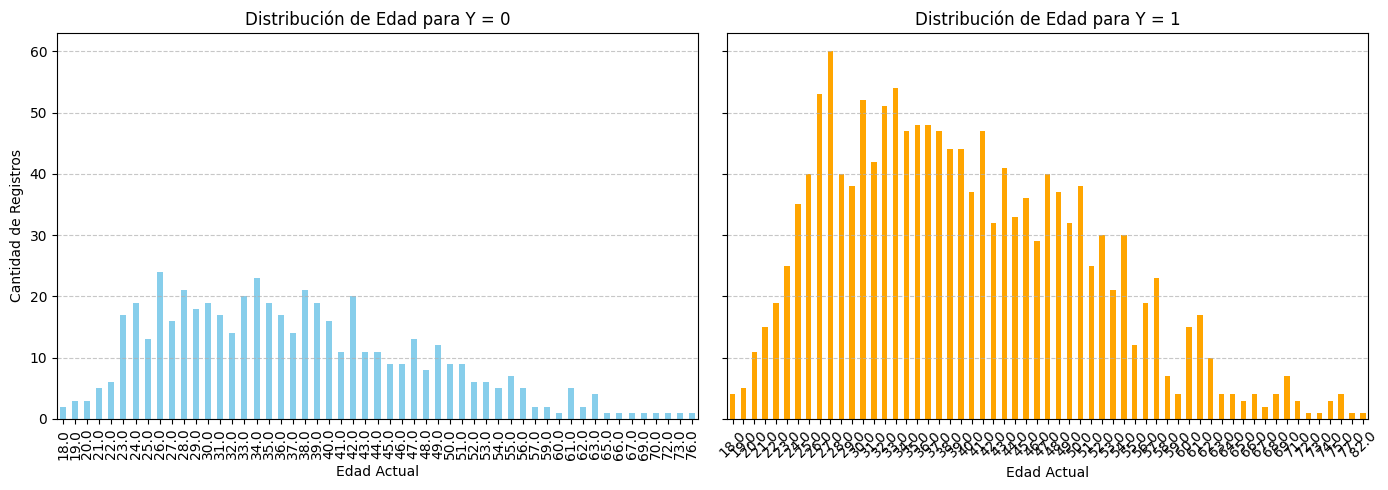

In [7]:
#import pandas as pd
#import matplotlib.pyplot as plt

# Filtrar datos según Y == 0
filtradoConfiables_0 = df.loc[df['Y'] == 0]
filtrado_0 = filtradoConfiables_0.query('Y == 0')
conteo_edades_0 = filtrado_0.groupby('EdadActual')[['Y']].count()

# Filtrar datos según Y == 1
filtradoConfiables_1 = df.loc[df['Y'] == 1]
filtrado_1 = filtradoConfiables_1.query('Y == 1')
conteo_edades_1 = filtrado_1.groupby('EdadActual')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico para Y = 0
conteo_edades_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de Edad para Y = 0")
axes[0].set_xlabel("Edad Actual")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1
conteo_edades_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de Edad para Y = 1")
axes[1].set_xlabel("Edad Actual")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


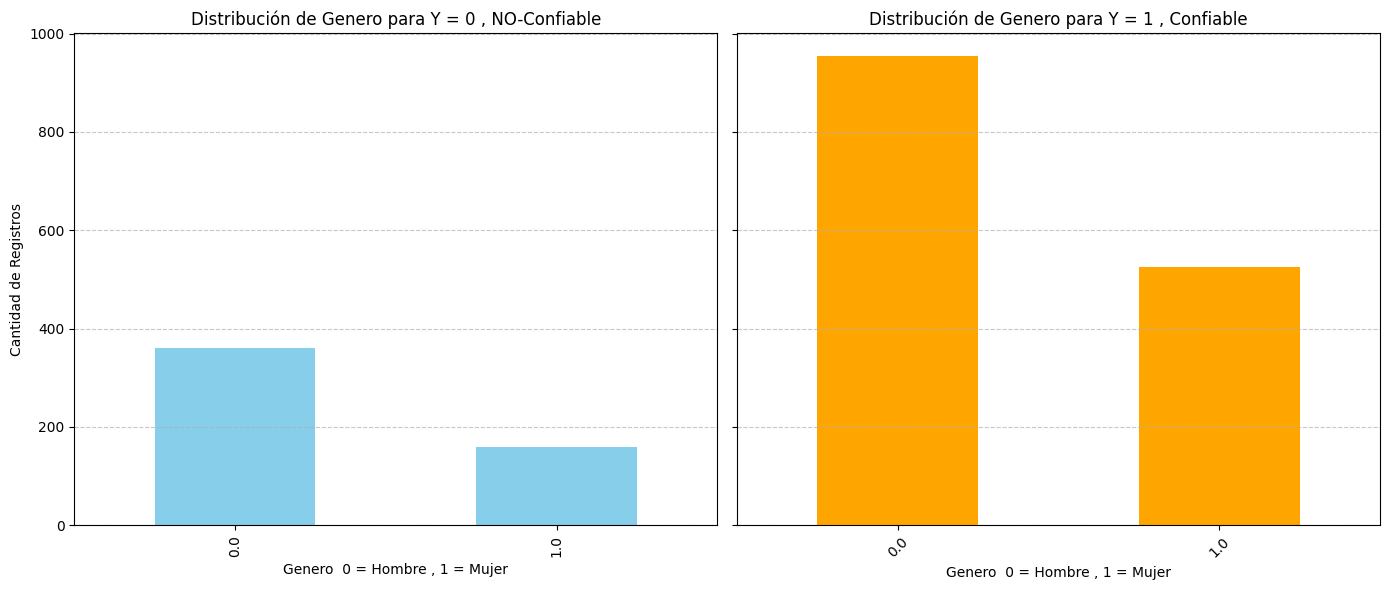

In [25]:
# Filtrar datos según Y == 0
filtradoConfiables_0 = df.loc[df['Y'] == 0]
filtrado_0 = filtradoConfiables_0.query('Y == 0')
conteo_edades_0 = filtrado_0.groupby('Genero')[['Y']].count()

# Filtrar datos según Y == 1
filtradoConfiables_1 = df.loc[df['Y'] == 1]
filtrado_1 = filtradoConfiables_1.query('Y == 1')
conteo_edades_1 = filtrado_1.groupby('Genero')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Gráfico para Y = 0
conteo_edades_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de Genero para Y = 0 , NO-Confiable")
axes[0].set_xlabel("Genero  0 = Hombre , 1 = Mujer")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1
conteo_edades_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de Genero para Y = 1 , Confiable")
axes[1].set_xlabel("Genero  0 = Hombre , 1 = Mujer")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

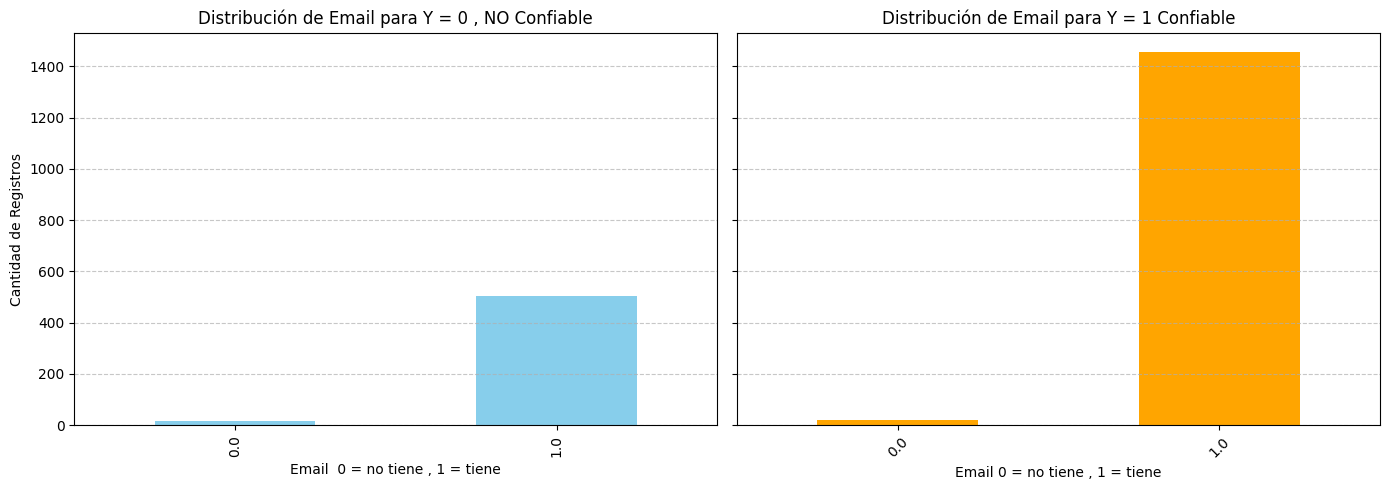

In [27]:
filtradoConfiables_0 = df.loc[df['Y'] == 0]
filtrado_0 = filtradoConfiables_0.query('Y == 0')
conteo_edades_0 = filtrado_0.groupby('Email')[['Y']].count()

# Filtrar datos según Y == 1
filtradoConfiables_1 = df.loc[df['Y'] == 1]
filtrado_1 = filtradoConfiables_1.query('Y == 1')
conteo_edades_1 = filtrado_1.groupby('Email')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico para Y = 0
conteo_edades_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de Email para Y = 0 , NO Confiable")
axes[0].set_xlabel("Email  0 = no tiene , 1 = tiene")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1
conteo_edades_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de Email para Y = 1 Confiable")
axes[1].set_xlabel("Email 0 = no tiene , 1 = tiene")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

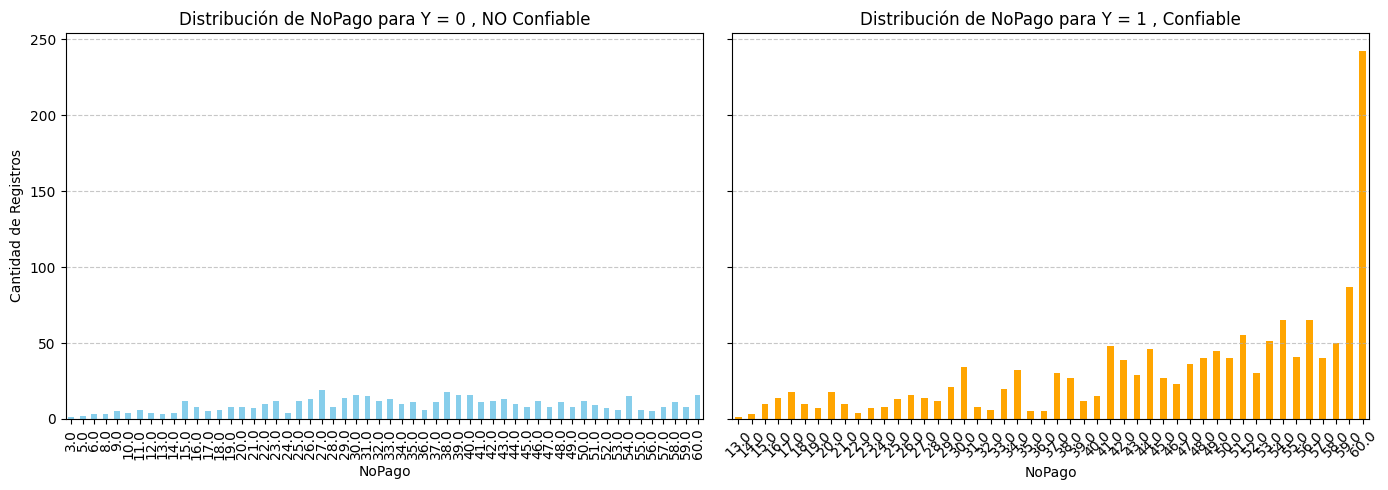

In [28]:
filtradoConfiables_0 = df.loc[df['Y'] == 0]
filtrado_0 = filtradoConfiables_0.query('Y == 0')
conteo_edades_0 = filtrado_0.groupby('NoPago')[['Y']].count()

# Filtrar datos según Y == 1
filtradoConfiables_1 = df.loc[df['Y'] == 1]
filtrado_1 = filtradoConfiables_1.query('Y == 1')
conteo_edades_1 = filtrado_1.groupby('NoPago')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico para Y = 0
conteo_edades_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de NoPago para Y = 0 , NO Confiable")
axes[0].set_xlabel("NoPago")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1
conteo_edades_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de NoPago para Y = 1 , Confiable")
axes[1].set_xlabel("NoPago")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Roland\AppData\Local\Temp\ipykernel_7372\2914343284.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mensualidad_0 = filtradoConfiables_0.groupby('Mensualidad_Rango')[['Y']].count()
C:\Users\Roland\AppData\Local\Temp\ipykernel_7372\2914343284.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mensualidad_1 = filtradoConfiables_1.groupby('Mensualidad_Rango')[['Y']].count()


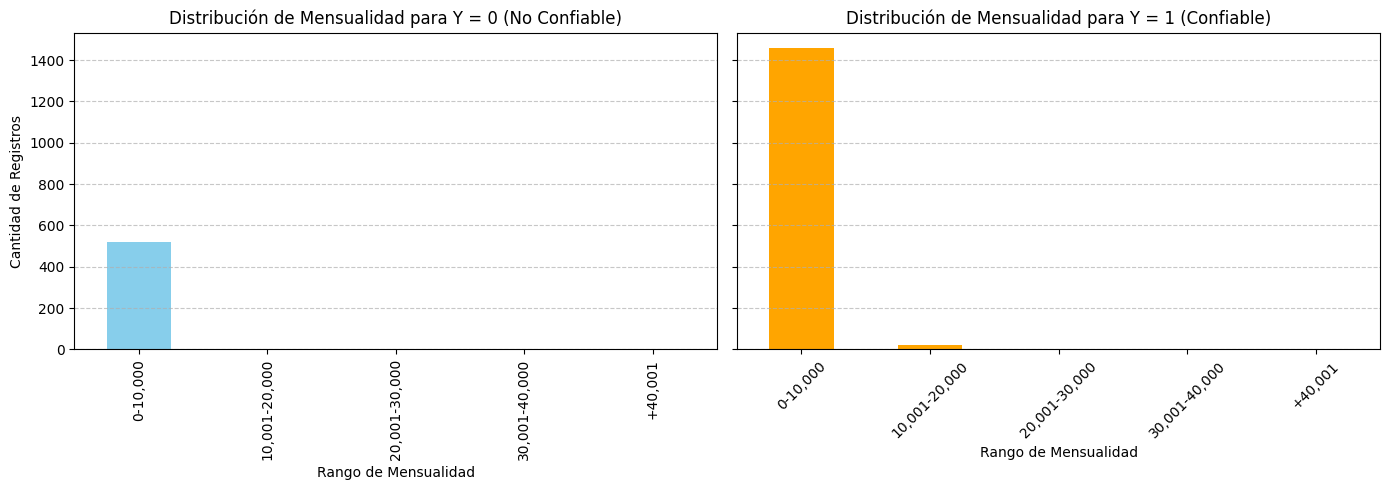

In [30]:

# Definir los rangos de Mensualidad (5 grupos)
bins = [0, 10000, 20000, 30000 , 40000, float('inf')]
labels = ['0-10,000', '10,001-20,000','20,001-30,000','30,001-40,000','+40,001']

# Crear nueva columna con los rangos
df['Mensualidad_Rango'] = pd.cut(df['Mensualidad'], bins=bins, labels=labels, right=True)

# Filtrar datos según Y == 0 (No confiables)
filtradoConfiables_0 = df[df['Y'] == 0]
conteo_mensualidad_0 = filtradoConfiables_0.groupby('Mensualidad_Rango')[['Y']].count()

# Filtrar datos según Y == 1 (Confiables)
filtradoConfiables_1 = df[df['Y'] == 1]
conteo_mensualidad_1 = filtradoConfiables_1.groupby('Mensualidad_Rango')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico para Y = 0 (NO confiable)
conteo_mensualidad_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de Mensualidad para Y = 0 (No Confiable)")
axes[0].set_xlabel("Rango de Mensualidad")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1 (Confiable)
conteo_mensualidad_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de Mensualidad para Y = 1 (Confiable)")
axes[1].set_xlabel("Rango de Mensualidad")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Roland\AppData\Local\Temp\ipykernel_7372\2185670285.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mensualidad_0 = filtradoConfiables_0.groupby('Mensualidad_Rango')[['Y']].count()
C:\Users\Roland\AppData\Local\Temp\ipykernel_7372\2185670285.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mensualidad_1 = filtradoConfiables_1.groupby('Mensualidad_Rango')[['Y']].count()


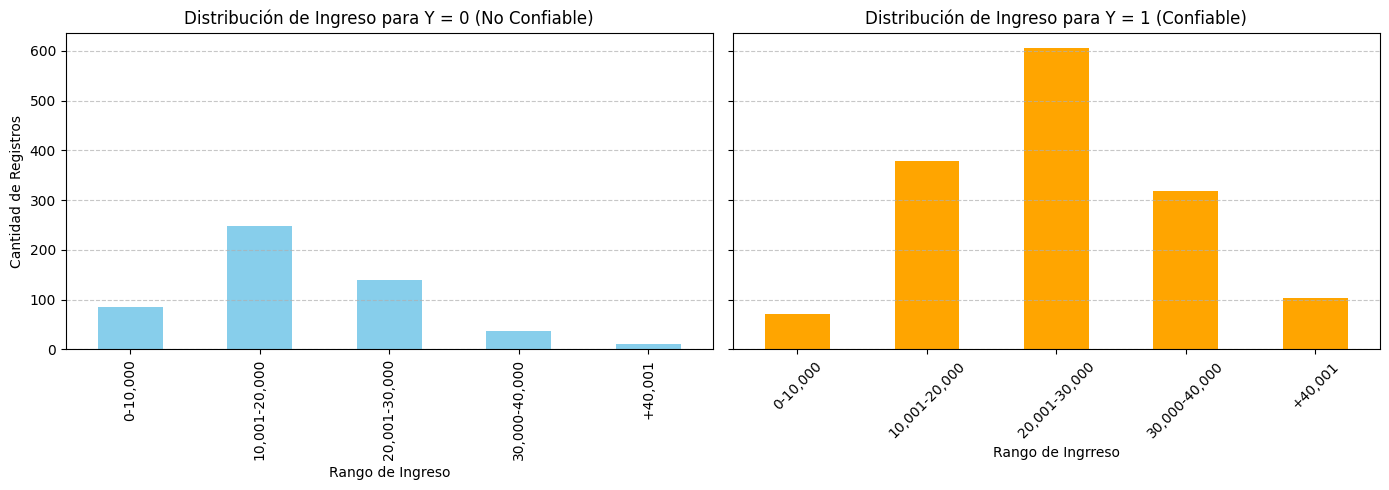

In [22]:
bins = [0, 10000, 20000, 30000, 40000,float('inf')]
labels = ['0-10,000', '10,001-20,000','20,001-30,000','30,000-40,000','+40,001']

# Crear nueva columna con los rangos
df['Mensualidad_Rango'] = pd.cut(df['Ingresos'], bins=bins, labels=labels, right=True)

# Filtrar datos según Y == 0 (No confiables)
filtradoConfiables_0 = df[df['Y'] == 0]
conteo_mensualidad_0 = filtradoConfiables_0.groupby('Mensualidad_Rango')[['Y']].count()

# Filtrar datos según Y == 1 (Confiables)
filtradoConfiables_1 = df[df['Y'] == 1]
conteo_mensualidad_1 = filtradoConfiables_1.groupby('Mensualidad_Rango')[['Y']].count()

# Crear gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico para Y = 0 (NO confiable)
conteo_mensualidad_0.plot(kind='bar', legend=False, color='skyblue', ax=axes[0])
axes[0].set_title("Distribución de Ingreso para Y = 0 (No Confiable)")
axes[0].set_xlabel("Rango de Ingreso")
axes[0].set_ylabel("Cantidad de Registros")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico para Y = 1 (Confiable)
conteo_mensualidad_1.plot(kind='bar', legend=False, color='orange', ax=axes[1])
axes[1].set_title("Distribución de Ingreso para Y = 1 (Confiable)")
axes[1].set_xlabel("Rango de Ingrreso")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
